<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_AR_AK_analyst_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_excel('/content/drive/MyDrive/Kalyani STUDY PATIENT.xlsx')

In [ ]:
df.columns

Index(['IP NUMBER ', 'NAME ', 'AGE', 'SEX', 'DIAGNOSIS', 'KH', 'KV', 'AX',
       'AL', 'ACD', 'LT', 'V/A PRE OP', 'POD 1 DAY V/A', 'SPH', 'CYL', 'AXIS',
       'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ', 'CYL.1', 'AXIS.1',
       'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1', 'CYL ', 'AXIS.2',
       'POD 3  MONTH    AR'],
      dtype='object')

In [ ]:
df.head()

,IP NUMBER,NAME,AGE,SEX,DIAGNOSIS,KH,KV,AX,AL,ACD,...,POD 6 WEEK V/A,SPH,CYL.1,AXIS.1,POD 6 WEEK AR,POD 3 MONTH V/A,SPH.1,CYL,AXIS.2,POD 3 MONTH AR
0,2682458,NAGAMMA,54,F,LE MC,46.50,47.25,155,22.65,2.76,...,6\12,0.25,-1.25,100.0,+0.25/-1.25/100,6\9,0.5,-1.0,65.0,+0.50/-1.00/65
1,2682462,GOWRAMMA,63,F,LE MC,46.75,48.00,80,21.90,1.99,...,6\18,0.75,-2.00,90.0,+0.75/-2.00/90,6\12,0.5,-2.0,80.0,+0.50/-2.00/80
2,2682451,SUNDRAMMA,78,F,RE BROWN CATARACT,44.00,44.25,20,22.91,3.08,...,6\24,-1.5,-1.00,140.0,-1.50/-1.00/140,NaN,NaN,NaN,NaN,NaN
3,2683506,KUNNABASAMMA,71,F,RE NS II + PSC,45.25,45.75,120,22.32,3.48,...,6\18,-0.5,-0.75,140.0,-0.5/-0.75/140,6\9,-0.5,-0.5,150.0,-0.5/-0.50/150
4,2689441,SANNAIAH,89,M,LE NS II + PSC + CC,45.50,47.00,80,22.31,3.06,...,6\12,0.25,2.25,85.0,+0.25/+2.25/85,NaN,NaN,NaN,NaN,NaN


In [ ]:
df1 = df.drop(['IP NUMBER ','DIAGNOSIS','AL', 'ACD', 'LT'], axis=1)
df1.columns


Index(['NAME ', 'AGE', 'SEX', 'KH', 'KV', 'AX', 'V/A PRE OP', 'POD 1 DAY V/A',
       'SPH', 'CYL', 'AXIS', 'POD 1 DAY  AR ', 'POD 6 WEEK V/A ', 'SPH ',
       'CYL.1', 'AXIS.1', 'POD 6 WEEK   AR ', 'POD 3 MONTH V/A', 'SPH.1',
       'CYL ', 'AXIS.2', 'POD 3  MONTH    AR'],
      dtype='object')

In [ ]:
day1AR = df[['KH','KV', 'AX', 'SPH', 'CYL', 'AXIS']].dropna(axis=0)
day1AR

,KH,KV,AX,SPH,CYL,AXIS
0,46.50,47.25,155,0.25,-1.50,115.0
1,46.75,48.00,80,0.75,-2.25,80.0
3,45.25,45.75,120,-0.75,-1.00,160.0
4,45.50,47.00,80,0.25,2.00,75.0
5,42.50,43.50,75,2,-2.00,90.0
...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0
167,47.00,48.25,165,1.25,-1.75,15.0
168,42.00,42.50,110,-0.75,-1.25,95.0
169,45.00,46.25,165,-2.75,-3.00,75.0


In [ ]:
day1AR.shape, day1AR.columns

((131, 6), Index(['KH', 'KV', 'AX', 'SPH', 'CYL', 'AXIS'], dtype='object'))

In [ ]:
# Create a new column 'Classification' in day1ARclean
day1AR['Classification'] = day1AR.apply(
    lambda row: 'compound Myopic Astigmatism' if row['SPH'] < 0 and row['CYL'] < 0 else
                'compound Hyperopic Astigmatism' if row['SPH'] > 0 and row['CYL'] > 0 else

                'simple myopic astigmatism' if row['SPH'] == 0 and row['CYL'] < 0 else
                'simple hyperopic astigmatism' if row['SPH'] == 0 and row['CYL'] > 0 else
                'mixed astigmatism',
    axis=1
)

# View result
print(day1AR[['SPH', 'CYL', 'AXIS','Classification']])

      SPH   CYL   AXIS                  Classification
0    0.25 -1.50  115.0               mixed astigmatism
1    0.75 -2.25   80.0               mixed astigmatism
3   -0.75 -1.00  160.0     compound Myopic Astigmatism
4    0.25  2.00   75.0  compound Hyperopic Astigmatism
5       2 -2.00   90.0               mixed astigmatism
..    ...   ...    ...                             ...
165 -2.75 -3.00   60.0     compound Myopic Astigmatism
167  1.25 -1.75   15.0               mixed astigmatism
168 -0.75 -1.25   95.0     compound Myopic Astigmatism
169 -2.75 -3.00   75.0     compound Myopic Astigmatism
173 -3.25 -3.00   40.0     compound Myopic Astigmatism

[131 rows x 4 columns]


In [ ]:
day1AR

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
0,46.50,47.25,155,0.25,-1.50,115.0,mixed astigmatism,0.75
1,46.75,48.00,80,0.75,-2.25,80.0,mixed astigmatism,1.25
3,45.25,45.75,120,-0.75,-1.00,160.0,compound Myopic Astigmatism,0.50
4,45.50,47.00,80,0.25,2.00,75.0,compound Hyperopic Astigmatism,1.50
5,42.50,43.50,75,2,-2.00,90.0,mixed astigmatism,1.00
...,...,...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0,compound Myopic Astigmatism,0.75
167,47.00,48.25,165,1.25,-1.75,15.0,mixed astigmatism,1.25
168,42.00,42.50,110,-0.75,-1.25,95.0,compound Myopic Astigmatism,0.50
169,45.00,46.25,165,-2.75,-3.00,75.0,compound Myopic Astigmatism,1.25


In [ ]:
# Frequency of each refractive error type
classification_counts = day1AR['Classification'].value_counts()
print(classification_counts)


Classification
mixed astigmatism                 62
compound Myopic Astigmatism       48
compound Hyperopic Astigmatism    14
simple myopic astigmatism          6
simple hyperopic astigmatism       1
Name: count, dtype: int64


In [ ]:
# Descriptive stats by classification group
grouped_stats = day1AR.groupby('Classification')[['SPH', 'CYL', 'AXIS']].describe()
print(grouped_stats)


                                 CYL                                           \
                               count      mean       std   min     25%    50%   
Classification                                                                  
compound Hyperopic Astigmatism  14.0  1.928571  1.178447  0.50  0.8125  1.750   
compound Myopic Astigmatism     48.0 -1.848958  1.248126 -4.75 -2.6250 -1.250   
mixed astigmatism               62.0 -2.080645  1.736053 -5.75 -2.9375 -2.125   
simple hyperopic astigmatism     1.0  1.000000       NaN  1.00  1.0000  1.000   
simple myopic astigmatism        6.0 -1.125000  0.564579 -2.00 -1.2500 -1.125   

                                            AXIS                               \
                                 75%   max count        mean        std   min   
Classification                                                                  
compound Hyperopic Astigmatism  3.00  3.75  14.0   97.000000  42.197339  18.0   
compound Myopic Astigmatism

In [ ]:
pivot = day1AR.pivot_table(index='Classification',
                                 values=['SPH', 'CYL', 'AXIS'],
                                 aggfunc=['mean', 'std', 'min', 'max', 'count'])
print(pivot)


                                      mean                            std  \
                                      AXIS       CYL       SPH       AXIS   
Classification                                                              
compound Hyperopic Astigmatism   97.000000  1.928571  1.214286  42.197339   
compound Myopic Astigmatism      93.125000 -1.848958     -1.25  43.924803   
mixed astigmatism                82.338710 -2.080645  1.096774  29.249040   
simple hyperopic astigmatism     90.000000  1.000000       0.0        NaN   
simple myopic astigmatism       111.666667 -1.125000       0.0  40.824829   

                                                     min                max  \
                                     CYL       SPH  AXIS   CYL   SPH   AXIS   
Classification                                                                
compound Hyperopic Astigmatism  1.178447  0.908598  18.0  0.50  0.25  175.0   
compound Myopic Astigmatism     1.248126  0.862949   5.0 -4.75 -3.2

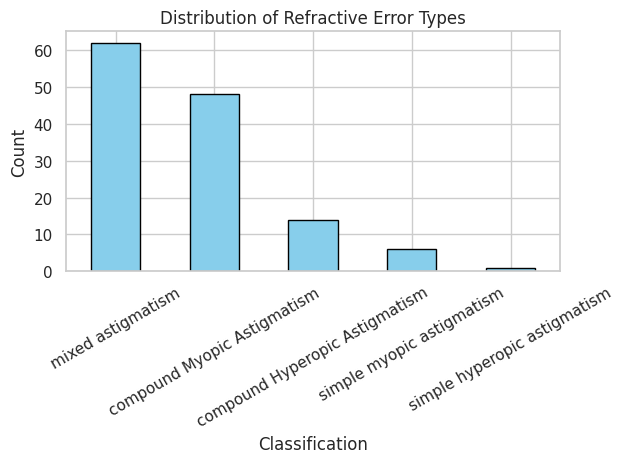

In [ ]:
import matplotlib.pyplot as plt

day1AR['Classification'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Refractive Error Types')
plt.xlabel('Classification')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


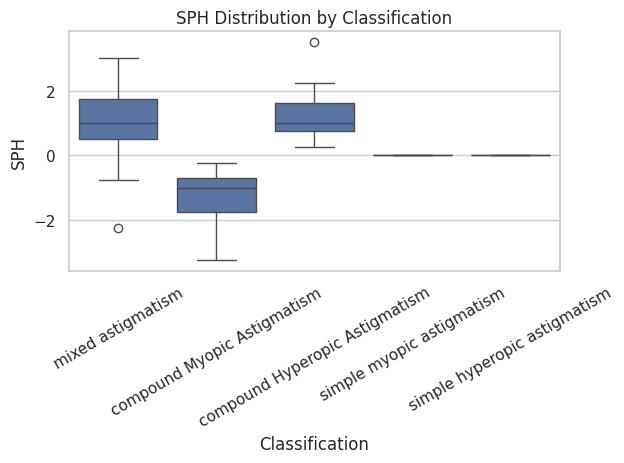

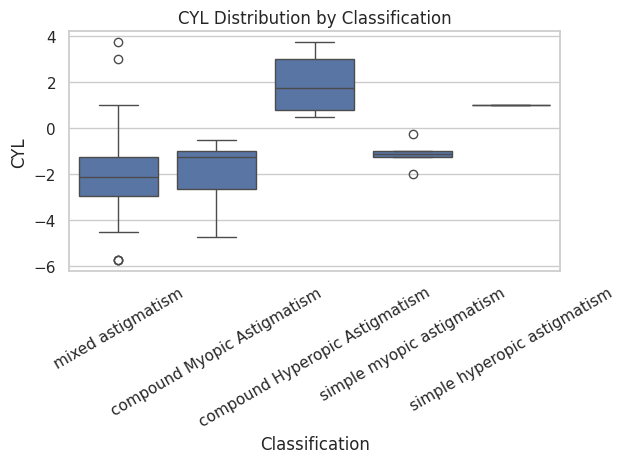

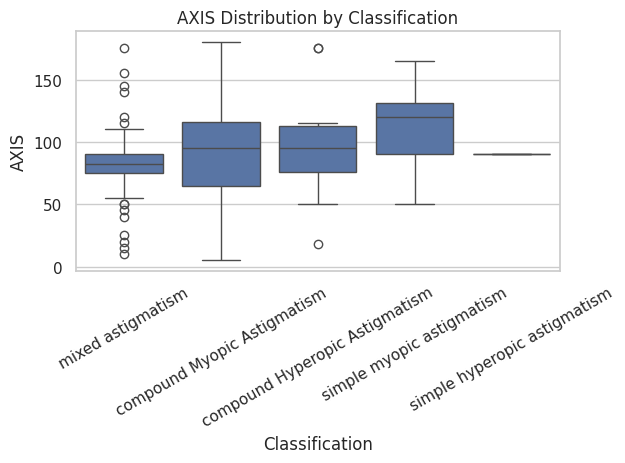

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# SPH boxplot
sns.boxplot(x='Classification', y='SPH', data=day1AR)
plt.title('SPH Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# CYL boxplot
sns.boxplot(x='Classification', y='CYL', data=day1AR)
plt.title('CYL Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# AXIS boxplot
sns.boxplot(x='Classification', y='AXIS', data=day1AR)
plt.title('AXIS Distribution by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
day1AR

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
0,46.50,47.25,155,0.25,-1.50,115.0,mixed astigmatism,0.75
1,46.75,48.00,80,0.75,-2.25,80.0,mixed astigmatism,1.25
3,45.25,45.75,120,-0.75,-1.00,160.0,compound Myopic Astigmatism,0.50
4,45.50,47.00,80,0.25,2.00,75.0,compound Hyperopic Astigmatism,1.50
5,42.50,43.50,75,2,-2.00,90.0,mixed astigmatism,1.00
...,...,...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0,compound Myopic Astigmatism,0.75
167,47.00,48.25,165,1.25,-1.75,15.0,mixed astigmatism,1.25
168,42.00,42.50,110,-0.75,-1.25,95.0,compound Myopic Astigmatism,0.50
169,45.00,46.25,165,-2.75,-3.00,75.0,compound Myopic Astigmatism,1.25


In [ ]:

# Separate Astigmatisms
mixed_df = day1AR[day1AR['Classification'] == 'mixed astigmatism']
C_myopic_df = day1AR[day1AR['Classification']=='compound Myopic Astigmatism']
C_hyperopic_df=day1AR[day1AR['Classification']=='compound Hyperopic Astigmatism']
S_myopic_df = day1AR[day1AR['Classification'] == 'simple myopic astigmatism']
S_hyperopic_df = day1AR[day1AR['Classification'] == 'simple hyperopic astigmatism']


In [ ]:
mixed_df.shape, C_myopic_df.shape, C_hyperopic_df.shape, S_myopic_df.shape, S_hyperopic_df.shape

((62, 8), (48, 8), (14, 8), (6, 8), (1, 8))

In [ ]:
mixed_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
0,46.50,47.25,155,0.25,-1.50,115.0,mixed astigmatism,0.75
1,46.75,48.00,80,0.75,-2.25,80.0,mixed astigmatism,1.25
5,42.50,43.50,75,2,-2.00,90.0,mixed astigmatism,1.00
6,43.50,44.00,20,-0.5,3.75,75.0,mixed astigmatism,0.50
8,44.75,45.25,85,1.5,-3.25,45.0,mixed astigmatism,0.50
...,...,...,...,...,...,...,...,...
149,45.25,45.50,30,2.5,-1.00,65.0,mixed astigmatism,0.25
155,44.25,45.75,80,1.25,-1.00,80.0,mixed astigmatism,1.50
159,41.75,43.50,160,-2.25,3.00,50.0,mixed astigmatism,1.75
163,45.25,45.25,180,1.75,-4.25,95.0,mixed astigmatism,0.00


In [ ]:
C_myopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
3,45.25,45.75,120,-0.75,-1.00,160.0,compound Myopic Astigmatism,0.50
7,43.00,44.50,90,-1,-0.50,100.0,compound Myopic Astigmatism,1.50
12,43.00,43.75,65,-1,-1.00,95.0,compound Myopic Astigmatism,0.75
17,44.75,45.25,80,-1.75,-1.25,15.0,compound Myopic Astigmatism,0.50
32,41.00,41.75,145,-0.5,-1.00,100.0,compound Myopic Astigmatism,0.75
37,43.25,44.00,125,-1.75,-3.75,80.0,compound Myopic Astigmatism,0.75
41,40.25,41.25,75,-1,-0.75,70.0,compound Myopic Astigmatism,1.00
42,44.00,44.25,140,-1.5,-1.00,50.0,compound Myopic Astigmatism,0.25
50,44.00,44.50,155,-0.75,-0.50,30.0,compound Myopic Astigmatism,0.50
52,45.00,45.25,175,-0.75,-1.25,75.0,compound Myopic Astigmatism,0.25


In [ ]:
C_hyperopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
4,45.50,47.00,80,0.25,2.00,75.0,compound Hyperopic Astigmatism,1.50
9,47.50,48.00,5,0.25,3.50,18.0,compound Hyperopic Astigmatism,0.50
19,43.75,45.00,85,2,3.00,105.0,compound Hyperopic Astigmatism,1.25
67,46.00,48.25,170,1,0.75,95.0,compound Hyperopic Astigmatism,2.25
76,44.50,44.75,55,1,0.50,95.0,compound Hyperopic Astigmatism,0.25
95,46.75,47.00,75,2.25,3.00,175.0,compound Hyperopic Astigmatism,0.25
110,44.00,45.50,90,1.75,2.25,100.0,compound Hyperopic Astigmatism,1.50
112,41.75,42.25,85,1.25,1.00,65.0,compound Hyperopic Astigmatism,0.50
113,45.25,46.00,90,1.25,0.75,115.0,compound Hyperopic Astigmatism,0.75
135,43.75,43.75,180,0.75,0.75,115.0,compound Hyperopic Astigmatism,0.00


In [ ]:
S_myopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
61,44.00,45.25,145,0,-1.25,120.0,simple myopic astigmatism,1.25
85,45.75,46.50,15,0,-1.00,120.0,simple myopic astigmatism,0.75
86,46.75,47.75,170,0,-2.00,165.0,simple myopic astigmatism,1.00
98,44.75,45.25,5,0,-0.25,50.0,simple myopic astigmatism,0.50
119,43.25,43.75,65,0,-1.00,135.0,simple myopic astigmatism,0.50
129,45.00,45.00,180,0,-1.25,80.0,simple myopic astigmatism,0.00


In [ ]:
S_hyperopic_df

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
130,45.75,46.0,15,0,1.0,90.0,simple hyperopic astigmatism,0.25


In [ ]:
mixed_df.describe()

,KH,KV,AX,CYL,AXIS,preopcyl
count,62.000000,62.000000,62.000000,62.000000,62.00000,62.000000
mean,44.544355,45.298387,108.306452,-2.080645,82.33871,0.754032
std,1.384579,1.449165,49.306199,1.736053,29.24904,0.486481
min,40.750000,41.750000,5.000000,-5.750000,10.00000,0.000000
25%,43.500000,44.500000,75.000000,-2.937500,75.00000,0.500000
50%,44.750000,45.250000,90.000000,-2.125000,82.50000,0.750000
75%,45.500000,46.000000,158.750000,-1.250000,90.00000,1.000000
max,47.500000,49.000000,180.000000,3.750000,175.00000,2.500000


In [ ]:
mixed_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS,preopcyl
KH,1.000000,0.942065,0.170112,0.108875,-0.229944,0.018143,-0.039819
KV,0.942065,1.000000,0.137963,0.075072,-0.169472,0.021459,0.297653
AX,0.170112,0.137963,1.000000,-0.229575,-0.048304,0.123569,-0.073181
SPH,0.108875,0.075072,-0.229575,1.000000,-0.541454,-0.091633,-0.086240
CYL,-0.229944,-0.169472,-0.048304,-0.541454,1.000000,0.092154,0.149611
AXIS,0.018143,0.021459,0.123569,-0.091633,0.092154,1.000000,0.012288
preopcyl,-0.039819,0.297653,-0.073181,-0.086240,0.149611,0.012288,1.000000


In [ ]:
C_myopic_df.describe()

,KH,KV,AX,CYL,AXIS,preopcyl
count,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000
mean,44.473958,45.312500,105.93750,-1.848958,93.125000,0.838542
std,1.896413,1.911958,49.05117,1.248126,43.924803,0.619904
min,40.000000,41.250000,10.00000,-4.750000,5.000000,0.000000
25%,43.250000,44.000000,68.75000,-2.625000,65.000000,0.500000
50%,44.750000,45.250000,102.50000,-1.250000,95.000000,0.750000
75%,46.000000,47.000000,151.25000,-1.000000,116.250000,1.000000
max,48.500000,49.500000,180.00000,-0.500000,180.000000,3.000000


In [ ]:
C_myopic_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS,preopcyl
KH,1.000000,0.947042,0.036293,-0.113761,-0.056731,0.112745,-0.138261
KV,0.947042,1.000000,-0.008578,-0.087045,-0.110474,0.084079,0.187088
AX,0.036293,-0.008578,1.000000,0.202318,0.372538,-0.190991,-0.137485
SPH,-0.113761,-0.087045,0.202318,1.000000,0.514843,0.159273,0.079547
CYL,-0.056731,-0.110474,0.372538,0.514843,1.000000,-0.033534,-0.167179
AXIS,0.112745,0.084079,-0.190991,0.159273,-0.033534,1.000000,-0.085587
preopcyl,-0.138261,0.187088,-0.137485,0.079547,-0.167179,-0.085587,1.000000


In [ ]:
C_hyperopic_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS,preopcyl
KH,1.000000,0.935679,-0.125804,0.253209,0.177276,0.212320,0.067502
KV,0.935679,1.000000,-0.080381,0.194104,0.133580,0.085255,0.415209
AX,-0.125804,-0.080381,1.000000,0.219173,-0.361098,0.475948,0.097062
SPH,0.253209,0.194104,0.219173,1.000000,0.329701,0.778452,-0.103980
CYL,0.177276,0.133580,-0.361098,0.329701,1.000000,0.118338,-0.079344
AXIS,0.212320,0.085255,0.475948,0.778452,0.118338,1.000000,-0.306338
preopcyl,0.067502,0.415209,0.097062,-0.103980,-0.079344,-0.306338,1.000000


In [ ]:
S_myopic_df.describe()

,KH,KV,AX,CYL,AXIS,preopcyl
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,44.916667,45.583333,96.666667,-1.125000,111.666667,0.666667
std,1.241639,1.375379,78.400680,0.564579,40.824829,0.437798
min,43.250000,43.750000,5.000000,-2.000000,50.000000,0.000000
25%,44.187500,45.062500,27.500000,-1.250000,90.000000,0.500000
50%,44.875000,45.250000,105.000000,-1.125000,120.000000,0.625000
75%,45.562500,46.187500,163.750000,-1.000000,131.250000,0.937500
max,46.750000,47.750000,180.000000,-0.250000,165.000000,1.250000


In [ ]:
S_myopic_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS,preopcyl
KH,1.000000,0.949119,0.199462,NaN,-0.499284,0.259750,0.145638
KV,0.949119,1.000000,0.200160,NaN,-0.563418,0.415557,0.449787
AX,0.199462,0.200160,1.000000,NaN,-0.790721,0.369191,0.063125
SPH,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CYL,-0.499284,-0.563418,-0.790721,NaN,1.000000,-0.813489,-0.354005
AXIS,0.259750,0.415557,0.369191,NaN,-0.813489,1.000000,0.568828
preopcyl,0.145638,0.449787,0.063125,NaN,-0.354005,0.568828,1.000000


In [ ]:
S_hyperopic_df.describe()

,KH,KV,AX,CYL,AXIS,preopcyl
count,1.00,1.0,1.0,1.0,1.0,1.00
mean,45.75,46.0,15.0,1.0,90.0,0.25
std,NaN,NaN,NaN,NaN,NaN,NaN
min,45.75,46.0,15.0,1.0,90.0,0.25
25%,45.75,46.0,15.0,1.0,90.0,0.25
50%,45.75,46.0,15.0,1.0,90.0,0.25
75%,45.75,46.0,15.0,1.0,90.0,0.25
max,45.75,46.0,15.0,1.0,90.0,0.25


In [ ]:
S_hyperopic_df.drop('Classification', axis=1).corr()

,KH,KV,AX,SPH,CYL,AXIS,preopcyl
KH,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KV,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SPH,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CYL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AXIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preopcyl,NaN,NaN,NaN,NaN,NaN,NaN,NaN


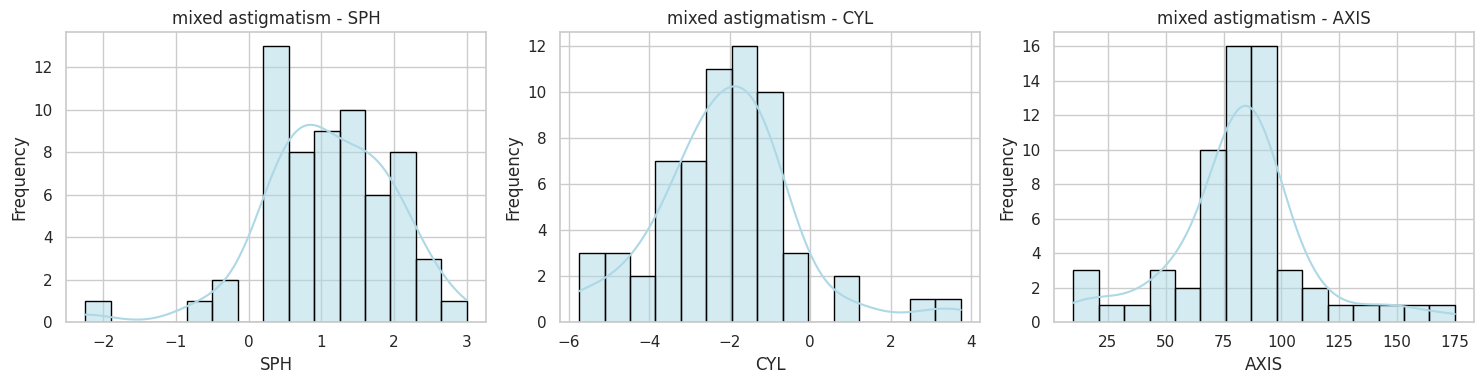

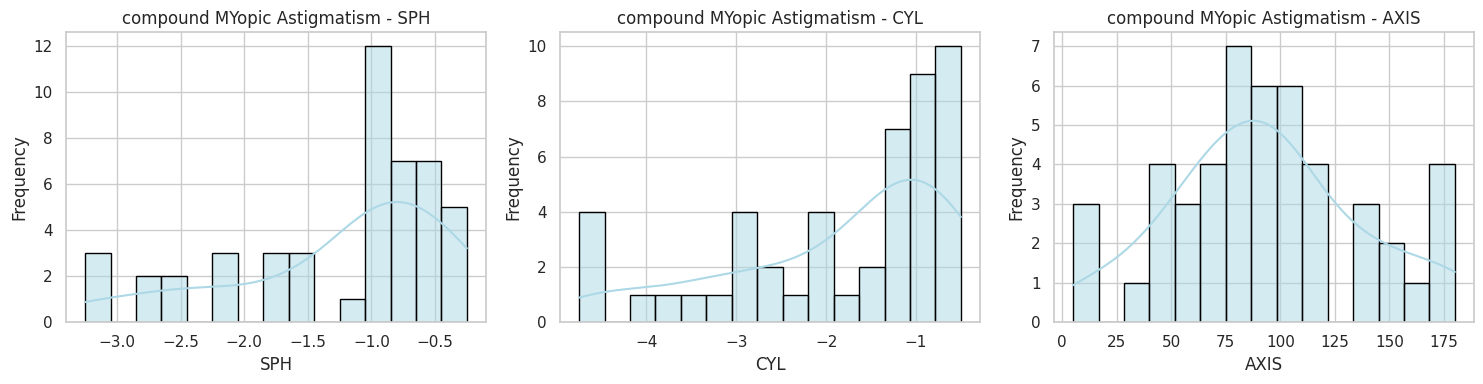

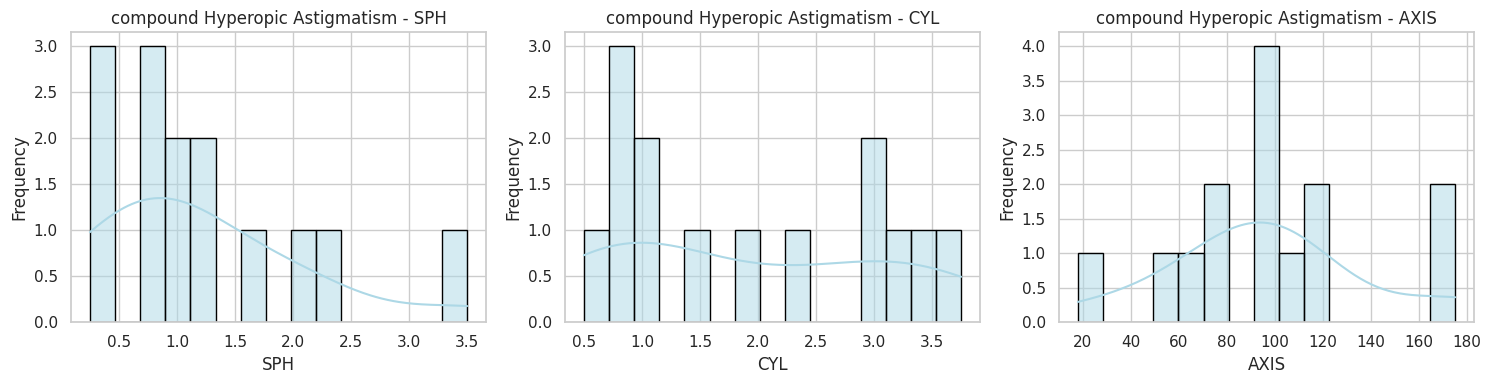

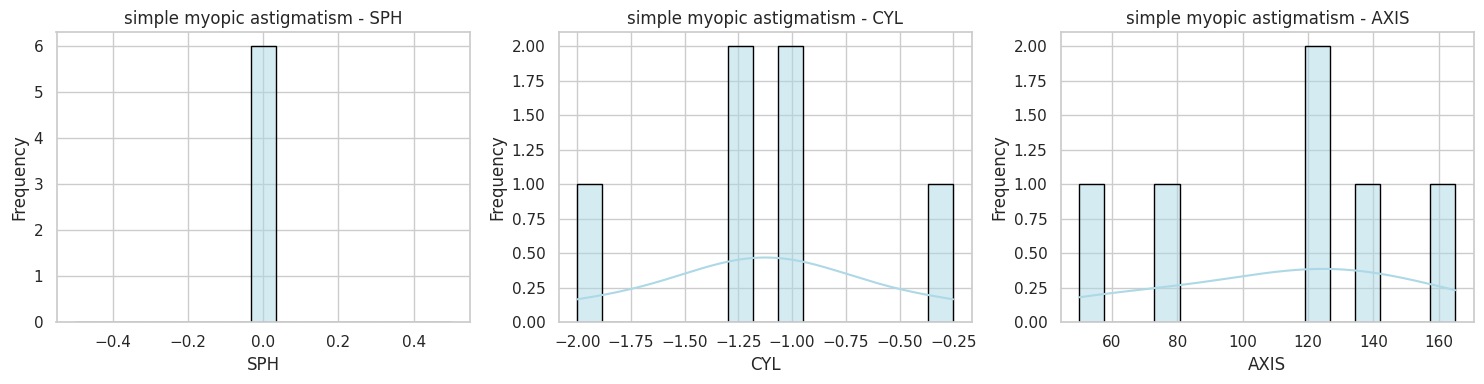

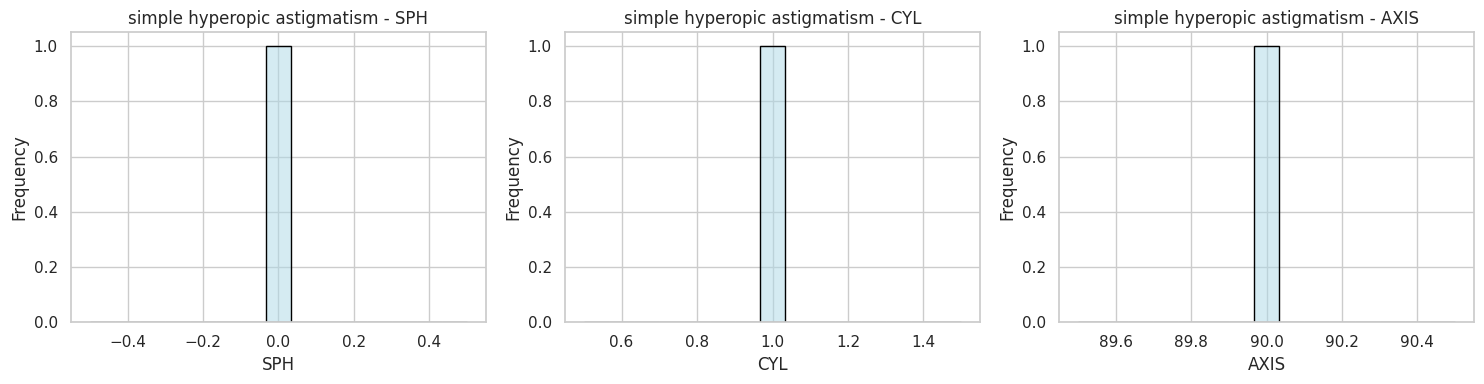

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_hist_with_kde(group_df, title_prefix):
    plt.figure(figsize=(15, 4))

    for i, col in enumerate(['SPH', 'CYL', 'AXIS']):
        plt.subplot(1, 3, i+1)
        sns.histplot(group_df[col].dropna(), kde=True, bins=15, color='lightblue', edgecolor='black')
        plt.title(f"{title_prefix} - {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Plot with bell curves for each group
#plot_hist_with_kde(myopic_df, "Myopic Astigmatism")
#plot_hist_with_kde(hyperopic_df, "Hyperopic Astigmatism")
plot_hist_with_kde(mixed_df, "mixed astigmatism")
plot_hist_with_kde(C_myopic_df, "compound MYopic Astigmatism")
plot_hist_with_kde(C_hyperopic_df, "compound Hyperopic Astigmatism")
plot_hist_with_kde(S_myopic_df, "simple myopic astigmatism")
plot_hist_with_kde(S_hyperopic_df, "simple hyperopic astigmatism")



/tmp/ipython-input-3708111262.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='SPH', data=day1AR, palette='pastel')


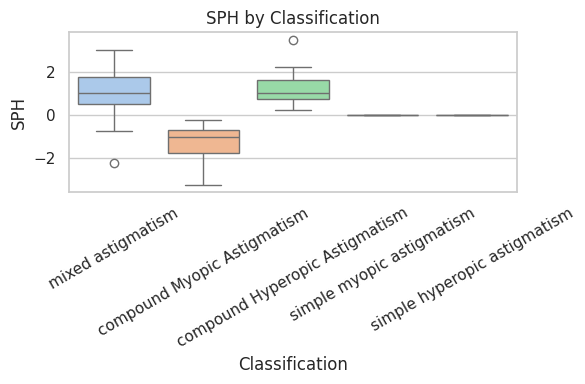

/tmp/ipython-input-3708111262.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='CYL', data=day1AR, palette='pastel')


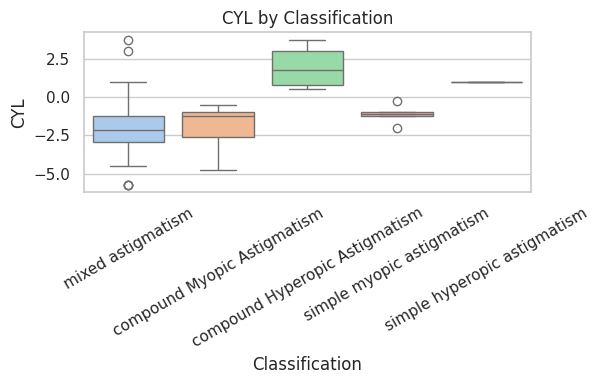

/tmp/ipython-input-3708111262.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classification', y='AXIS', data=day1AR, palette='pastel')


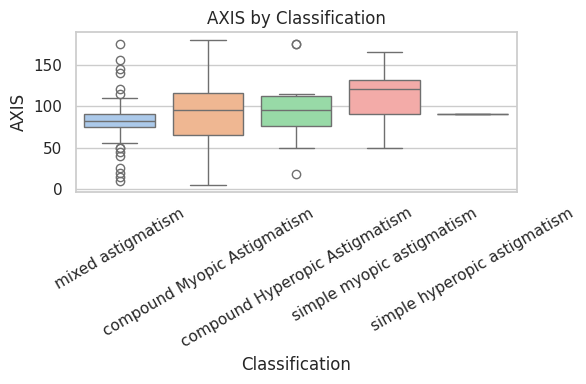

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Boxplot for SPH
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='SPH', data=day1AR, palette='pastel')
plt.title('SPH by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot for CYL
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='CYL', data=day1AR, palette='pastel')
plt.title('CYL by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Boxplot for AXIS
plt.figure(figsize=(6, 4))
sns.boxplot(x='Classification', y='AXIS', data=day1AR, palette='pastel')
plt.title('AXIS by Classification')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
day1AR['preopcyl'] = day1AR['KV']-day1AR['KH']
day1AR

,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
0,46.50,47.25,155,0.25,-1.50,115.0,mixed astigmatism,0.75
1,46.75,48.00,80,0.75,-2.25,80.0,mixed astigmatism,1.25
3,45.25,45.75,120,-0.75,-1.00,160.0,compound Myopic Astigmatism,0.50
4,45.50,47.00,80,0.25,2.00,75.0,compound Hyperopic Astigmatism,1.50
5,42.50,43.50,75,2,-2.00,90.0,mixed astigmatism,1.00
...,...,...,...,...,...,...,...,...
165,43.25,44.00,60,-2.75,-3.00,60.0,compound Myopic Astigmatism,0.75
167,47.00,48.25,165,1.25,-1.75,15.0,mixed astigmatism,1.25
168,42.00,42.50,110,-0.75,-1.25,95.0,compound Myopic Astigmatism,0.50
169,45.00,46.25,165,-2.75,-3.00,75.0,compound Myopic Astigmatism,1.25


In [ ]:
C_myopic_df['preopcyl'] = C_myopic_df['KV']-C_myopic_df['KH']

C_myopic_df

/tmp/ipython-input-1174676577.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_myopic_df['preopcyl'] = C_myopic_df['KV']-C_myopic_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
3,45.25,45.75,120,-0.75,-1.00,160.0,compound Myopic Astigmatism,0.50
7,43.00,44.50,90,-1,-0.50,100.0,compound Myopic Astigmatism,1.50
12,43.00,43.75,65,-1,-1.00,95.0,compound Myopic Astigmatism,0.75
17,44.75,45.25,80,-1.75,-1.25,15.0,compound Myopic Astigmatism,0.50
32,41.00,41.75,145,-0.5,-1.00,100.0,compound Myopic Astigmatism,0.75
37,43.25,44.00,125,-1.75,-3.75,80.0,compound Myopic Astigmatism,0.75
41,40.25,41.25,75,-1,-0.75,70.0,compound Myopic Astigmatism,1.00
42,44.00,44.25,140,-1.5,-1.00,50.0,compound Myopic Astigmatism,0.25
50,44.00,44.50,155,-0.75,-0.50,30.0,compound Myopic Astigmatism,0.50
52,45.00,45.25,175,-0.75,-1.25,75.0,compound Myopic Astigmatism,0.25


In [ ]:
C_hyperopic_df['preopcyl'] = C_hyperopic_df['KV']-C_hyperopic_df['KH']
C_hyperopic_df


/tmp/ipython-input-2999170323.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  C_hyperopic_df['preopcyl'] = C_hyperopic_df['KV']-C_hyperopic_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
4,45.50,47.00,80,0.25,2.00,75.0,compound Hyperopic Astigmatism,1.50
9,47.50,48.00,5,0.25,3.50,18.0,compound Hyperopic Astigmatism,0.50
19,43.75,45.00,85,2,3.00,105.0,compound Hyperopic Astigmatism,1.25
67,46.00,48.25,170,1,0.75,95.0,compound Hyperopic Astigmatism,2.25
76,44.50,44.75,55,1,0.50,95.0,compound Hyperopic Astigmatism,0.25
95,46.75,47.00,75,2.25,3.00,175.0,compound Hyperopic Astigmatism,0.25
110,44.00,45.50,90,1.75,2.25,100.0,compound Hyperopic Astigmatism,1.50
112,41.75,42.25,85,1.25,1.00,65.0,compound Hyperopic Astigmatism,0.50
113,45.25,46.00,90,1.25,0.75,115.0,compound Hyperopic Astigmatism,0.75
135,43.75,43.75,180,0.75,0.75,115.0,compound Hyperopic Astigmatism,0.00


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl


In [ ]:
S_myopic_df['preopcyl'] = S_myopic_df['KV']-S_myopic_df['KH']

S_myopic_df

/tmp/ipython-input-1372354867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_myopic_df['preopcyl'] = S_myopic_df['KV']-S_myopic_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
61,44.00,45.25,145,0,-1.25,120.0,simple myopic astigmatism,1.25
85,45.75,46.50,15,0,-1.00,120.0,simple myopic astigmatism,0.75
86,46.75,47.75,170,0,-2.00,165.0,simple myopic astigmatism,1.00
98,44.75,45.25,5,0,-0.25,50.0,simple myopic astigmatism,0.50
119,43.25,43.75,65,0,-1.00,135.0,simple myopic astigmatism,0.50
129,45.00,45.00,180,0,-1.25,80.0,simple myopic astigmatism,0.00


In [ ]:
S_hyperopic_df['preopcyl'] = S_hyperopic_df['KV']-S_hyperopic_df['KH']
S_hyperopic_df

/tmp/ipython-input-1900593351.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  S_hyperopic_df['preopcyl'] = S_hyperopic_df['KV']-S_hyperopic_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl
130,45.75,46.0,15,0,1.0,90.0,simple hyperopic astigmatism,0.25


## Mixed astigmatism SIA vector analysis

In [ ]:
import numpy as np
import pandas as pd

# Assuming mixed_df is already defined
# Step 1: Pre- and Post-op Cylinder
mixed_df['preopcyl'] = mixed_df['KV'] - mixed_df['KH']
mixed_df['postopcyl'] = mixed_df['CYL']  # or use another post-op column if different

# Step 2: Convert axis to double angle in radians
mixed_df['pre_theta'] = np.deg2rad(mixed_df['AX'] * 2)
mixed_df['post_theta'] = np.deg2rad(mixed_df['AXIS'] * 2)

# Step 3: Convert to Cartesian coordinates
mixed_df['pre_x'] = mixed_df['preopcyl'] * np.cos(mixed_df['pre_theta'])
mixed_df['pre_y'] = mixed_df['preopcyl'] * np.sin(mixed_df['pre_theta'])

mixed_df['post_x'] = mixed_df['postopcyl'] * np.cos(mixed_df['post_theta'])
mixed_df['post_y'] = mixed_df['postopcyl'] * np.sin(mixed_df['post_theta'])

# Step 4: Compute SIA vector components
mixed_df['sia_x'] = mixed_df['post_x'] - mixed_df['pre_x']
mixed_df['sia_y'] = mixed_df['post_y'] - mixed_df['pre_y']

# Step 5: Compute SIA magnitude and axis
mixed_df['SIA_magnitude'] = np.sqrt(mixed_df['sia_x']**2 + mixed_df['sia_y']**2)
mixed_df['SIA_axis'] = (np.rad2deg(np.arctan2(mixed_df['sia_y'], mixed_df['sia_x'])) / 2) % 180

# Step 6: Round for neat display
mixed_df['SIA_magnitude'] = mixed_df['SIA_magnitude'].round(2)
mixed_df['SIA_axis'] = mixed_df['SIA_axis'].round(1)

# Show the final results
print(mixed_df[['SIA_magnitude', 'SIA_axis']])


     SIA_magnitude  SIA_axis
0             1.79      37.2
1             3.50     170.0
5             2.91     175.1
6             3.95      78.4
8             3.37     139.2
..             ...       ...
149           1.11     148.9
155           2.50     170.0
159           4.48      57.3
163           4.25       5.0
167           2.61      92.7

[62 rows x 2 columns]


/tmp/ipython-input-1142109466.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df['preopcyl'] = mixed_df['KV'] - mixed_df['KH']
/tmp/ipython-input-1142109466.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df['postopcyl'] = mixed_df['CYL']  # or use another post-op column if different
/tmp/ipython-input-1142109466.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [179]:
mixed_df['preopcyl'] = mixed_df['KV']-mixed_df['KH']
mixed_df


/tmp/ipython-input-3961326065.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_df['preopcyl'] = mixed_df['KV']-mixed_df['KH']


,KH,KV,AX,SPH,CYL,AXIS,Classification,preopcyl,postopcyl,pre_theta,post_theta,pre_x,pre_y,post_x,post_y,sia_x,sia_y,SIA_magnitude,SIA_axis
0,46.50,47.25,155,0.25,-1.50,115.0,mixed astigmatism,0.75,-1.50,5.410521,4.014257,0.482091,-0.574533,9.641814e-01,1.149067e+00,0.482091,1.723600,1.79,37.2
1,46.75,48.00,80,0.75,-2.25,80.0,mixed astigmatism,1.25,-2.25,2.792527,2.792527,-1.174616,0.427525,2.114308e+00,-7.695453e-01,3.288924,-1.197071,3.50,170.0
5,42.50,43.50,75,2,-2.00,90.0,mixed astigmatism,1.00,-2.00,2.617994,3.141593,-0.866025,0.500000,2.000000e+00,-2.449294e-16,2.866025,-0.500000,2.91,175.1
6,43.50,44.00,20,-0.5,3.75,75.0,mixed astigmatism,0.50,3.75,0.698132,2.617994,0.383022,0.321394,-3.247595e+00,1.875000e+00,-3.630617,1.553606,3.95,78.4
8,44.75,45.25,85,1.5,-3.25,45.0,mixed astigmatism,0.50,-3.25,2.967060,1.570796,-0.492404,0.086824,-1.990051e-16,-3.250000e+00,0.492404,-3.336824,3.37,139.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,45.25,45.50,30,2.5,-1.00,65.0,mixed astigmatism,0.25,-1.00,1.047198,2.268928,0.125000,0.216506,6.427876e-01,-7.660444e-01,0.517788,-0.982551,1.11,148.9
155,44.25,45.75,80,1.25,-1.00,80.0,mixed astigmatism,1.50,-1.00,2.792527,2.792527,-1.409539,0.513030,9.396926e-01,-3.420201e-01,2.349232,-0.855050,2.50,170.0
159,41.75,43.50,160,-2.25,3.00,50.0,mixed astigmatism,1.75,3.00,5.585054,1.745329,1.340578,-1.124878,-5.209445e-01,2.954423e+00,-1.861522,4.079302,4.48,57.3
163,45.25,45.25,180,1.75,-4.25,95.0,mixed astigmatism,0.00,-4.25,6.283185,3.316126,0.000000,-0.000000,4.185433e+00,7.380048e-01,4.185433,0.738005,4.25,5.0


In [166]:
import numpy as np

def to_cartesian(cyl, axis_deg):
    # Convert cylinder vector to X, Y components
    angle_rad = np.deg2rad(2 * axis_deg)  # double angle for astigmatism
    x = cyl * np.cos(angle_rad)
    y = cyl * np.sin(angle_rad)
    return x, y

def from_cartesian(x, y):
    # Convert X, Y to cylinder and axis
    cyl = np.hypot(x, y)  # magnitude
    axis = np.rad2deg(np.arctan2(y, x)) / 2  # halve angle back
    if axis < 0:
        axis += 180  # normalize between 0-180
    return cyl, axis

def calculate_sia(pre_cyl, pre_axis, post_cyl, post_axis):
    # Convert pre- and post-op to Cartesian
    x_pre, y_pre = to_cartesian(pre_cyl, pre_axis)
    x_post, y_post = to_cartesian(post_cyl, post_axis)

    # SIA vector = post - pre
    x_sia = x_post - x_pre
    y_sia = y_post - y_pre

    # SIA magnitude and axis
    sia_mag, sia_axis = from_cartesian(x_sia, y_sia)

    print(f"Pre-op vector (X, Y): ({x_pre:.2f}, {y_pre:.2f})")
    print(f"Post-op vector (X, Y): ({x_post:.2f}, {y_post:.2f})")
    print(f"SIA vector (X, Y): ({x_sia:.2f}, {y_sia:.2f})")
    print(f"SIA Magnitude: {sia_mag:.2f} D")
    print(f"SIA Axis: {sia_axis:.2f}°")

# Example input (in diopters and degrees)
pre_cyl = 0.75
pre_axis = 155
post_cyl = -1.50
post_axis = 115

calculate_sia(pre_cyl, pre_axis, post_cyl, post_axis)


Pre-op vector (X, Y): (0.48, -0.57)
Post-op vector (X, Y): (0.96, 1.15)
SIA vector (X, Y): (0.48, 1.72)
SIA Magnitude: 1.79 D
SIA Axis: 37.19°


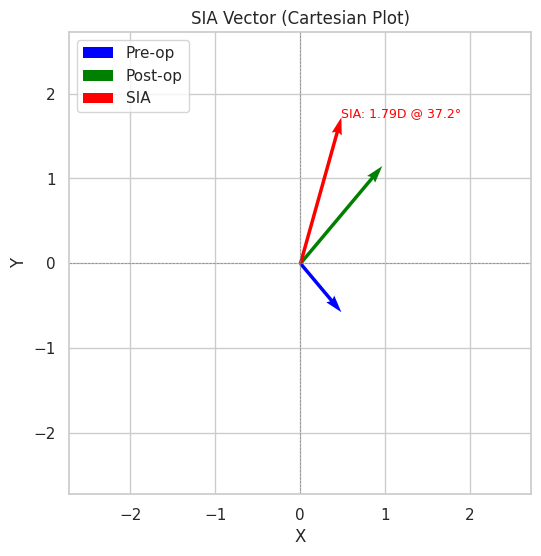

In [168]:
import numpy as np
import matplotlib.pyplot as plt

# Function to convert cylinder and axis to X, Y components
def to_cartesian(cyl, axis_deg):
    angle_rad = np.deg2rad(2 * axis_deg)  # double angle
    x = cyl * np.cos(angle_rad)
    y = cyl * np.sin(angle_rad)
    return x, y

# Function to convert X, Y back to magnitude and axis
def from_cartesian(x, y):
    cyl = np.hypot(x, y)
    axis = np.rad2deg(np.arctan2(y, x)) / 2
    if axis < 0:
        axis += 180
    return cyl, axis

# Main function
def plot_sia_vector(pre_cyl, pre_axis, post_cyl, post_axis):
    # Convert to Cartesian
    x_pre, y_pre = to_cartesian(pre_cyl, pre_axis)
    x_post, y_post = to_cartesian(post_cyl, post_axis)

    # SIA = post - pre
    x_sia = x_post - x_pre
    y_sia = y_post - y_pre
    sia_mag, sia_axis = from_cartesian(x_sia, y_sia)

    # Plot setup
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)

    # Plot vectors from origin
    plt.quiver(0, 0, x_pre, y_pre, angles='xy', scale_units='xy', scale=1, color='blue', label='Pre-op')
    plt.quiver(0, 0, x_post, y_post, angles='xy', scale_units='xy', scale=1, color='green', label='Post-op')
    plt.quiver(0, 0, x_sia, y_sia, angles='xy', scale_units='xy', scale=1, color='red', label='SIA')

    # Annotate
    plt.text(x_sia, y_sia, f'SIA: {sia_mag:.2f}D @ {sia_axis:.1f}°', color='red', fontsize=9)

    # Axes limits
    max_val = max(abs(x_pre), abs(y_pre), abs(x_post), abs(y_post), abs(x_sia), abs(y_sia)) + 1
    plt.xlim(-max_val, max_val)
    plt.ylim(-max_val, max_val)

    plt.title("SIA Vector (Cartesian Plot)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Sample input
pre_cyl = 0.75
pre_axis = 155
post_cyl = -1.50
post_axis = 115

plot_sia_vector(pre_cyl, pre_axis, post_cyl, post_axis)


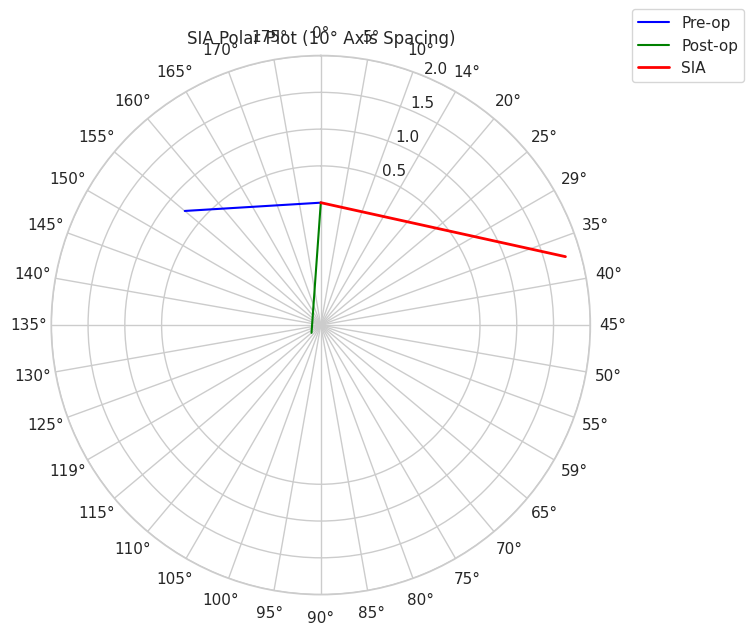

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# Convert cylinder and axis to polar (double angle)
def to_polar(cyl, axis_deg):
    theta_rad = np.deg2rad(2 * axis_deg)
    r = cyl
    return theta_rad, r

# Compute SIA vector from pre- and post-op astigmatism
def compute_sia(pre_cyl, pre_axis, post_cyl, post_axis):
    x_pre = pre_cyl * np.cos(np.deg2rad(2 * pre_axis))
    y_pre = pre_cyl * np.sin(np.deg2rad(2 * pre_axis))
    x_post = post_cyl * np.cos(np.deg2rad(2 * post_axis))
    y_post = post_cyl * np.sin(np.deg2rad(2 * post_axis))

    x_sia = x_post - x_pre
    y_sia = y_post - y_pre

    r_sia = np.hypot(x_sia, y_sia)
    theta_sia = np.rad2deg(np.arctan2(y_sia, x_sia)) / 2
    if theta_sia < 0:
        theta_sia += 180
    return r_sia, np.deg2rad(2 * theta_sia)

# Polar plot with 10° spacing
def plot_polar_sia(pre_cyl, pre_axis, post_cyl, post_axis):
    theta_pre, r_pre = to_polar(pre_cyl, pre_axis)
    theta_post, r_post = to_polar(post_cyl, post_axis)
    r_sia, theta_sia = compute_sia(pre_cyl, pre_axis, post_cyl, post_axis)

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, polar=True)
    ax.set_theta_zero_location("N")  # 0° at top
    ax.set_theta_direction(-1)       # Clockwise

    # Plot vectors
    ax.plot([0, theta_pre], [0, r_pre], label='Pre-op', color='blue')
    ax.plot([0, theta_post], [0, r_post], label='Post-op', color='green')
    ax.plot([0, theta_sia], [0, r_sia], label='SIA', color='red', linewidth=2)

    # 10-degree spacing for angular ticks (every 10°, from 0° to 350°)
    angles = np.deg2rad(np.arange(0, 360, 10))
    angle_labels = [f"{int(np.rad2deg(a)/2)%180}°" for a in angles]  # halve back and wrap to 0–180°
    ax.set_xticks(angles)
    ax.set_xticklabels(angle_labels)

    # Radial ticks (adjust as needed)
    ax.set_rticks([0.5, 1.0, 1.5, 2.0])

    ax.set_title("SIA Polar Plot (10° Axis Spacing)", va='bottom')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Example
pre_cyl = 0.75
pre_axis = 155
post_cyl = -1.50
post_axis = 115

plot_polar_sia(pre_cyl, pre_axis, post_cyl, post_axis)


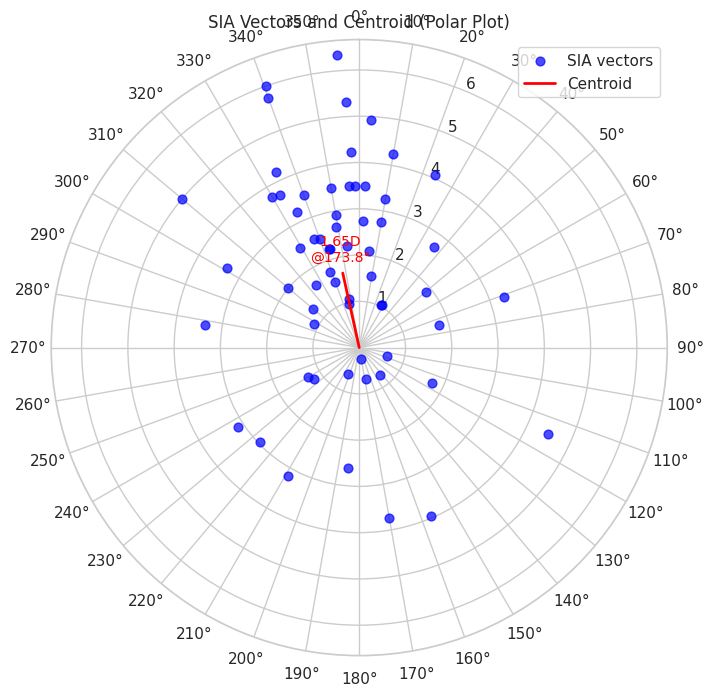

In [171]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns exist
required_cols = ['sia_x', 'sia_y', 'SIA_magnitude', 'SIA_axis']
missing_cols = [col for col in required_cols if col not in mixed_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = mixed_df['sia_x'].mean()
centroid_y = mixed_df['sia_y'].mean()
centroid_mag = np.sqrt(centroid_x**2 + centroid_y**2)
centroid_axis = (np.rad2deg(np.arctan2(centroid_y, centroid_x)) / 2) % 180
centroid_theta = np.deg2rad(centroid_axis * 2)

# --- Convert data points to polar ---
theta = np.deg2rad(mixed_df['SIA_axis'] * 2)  # double-angle domain
r = mixed_df['SIA_magnitude']

# --- Plot ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(np.arange(0, 360, 10))  # 10° spacing

# Plot SIA data points
ax.scatter(theta, r, color='blue', s=40, alpha=0.7, label='SIA vectors')

# Plot centroid vector
ax.plot([0, centroid_theta], [0, centroid_mag], color='red', linewidth=2, label='Centroid')

# Label the centroid
ax.text(centroid_theta, centroid_mag + 0.2,
        f"{centroid_mag:.2f}D\n@{centroid_axis:.1f}°",
        ha='center', va='bottom', fontsize=10, color='red')

# Final formatting
ax.set_title("SIA Vectors and Centroid (Polar Plot)", va='bottom')
ax.legend(loc='upper right')
ax.grid(True)
plt.show()


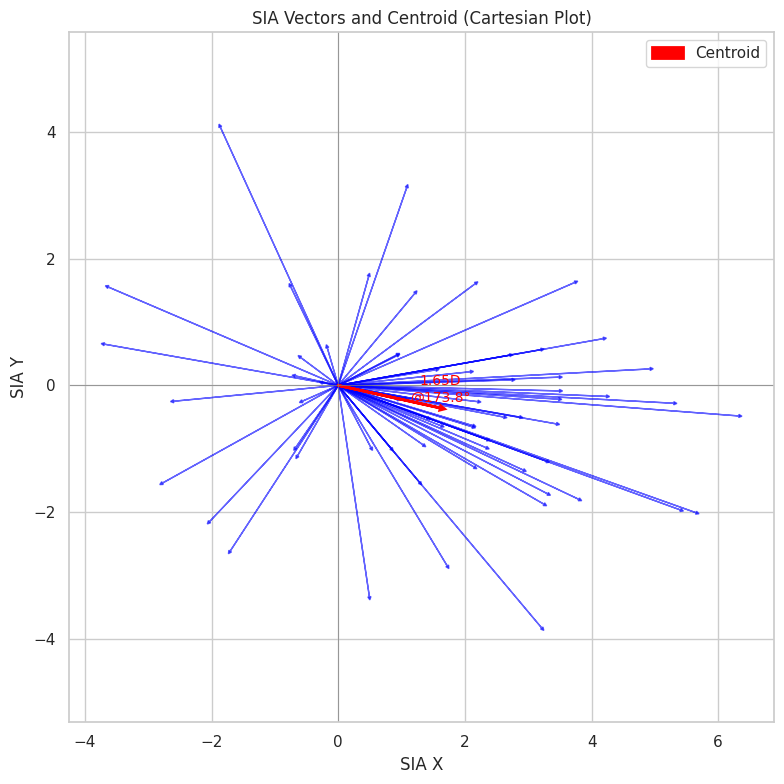

In [172]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure required columns
required_cols = ['sia_x', 'sia_y']
missing_cols = [col for col in required_cols if col not in mixed_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# --- Compute centroid ---
centroid_x = mixed_df['sia_x'].mean()
centroid_y = mixed_df['sia_y'].mean()

# --- Plot setup ---
plt.figure(figsize=(8, 8))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

# Plot all SIA vectors
for i, row in mixed_df.iterrows():
    plt.arrow(0, 0, row['sia_x'], row['sia_y'],
              head_width=0.05, head_length=0.05,
              fc='blue', ec='blue', alpha=0.6)

# Plot centroid vector
plt.arrow(0, 0, centroid_x, centroid_y,
          head_width=0.07, head_length=0.07,
          fc='red', ec='red', lw=2, label='Centroid')

# Add centroid label at the tip
plt.text(centroid_x, centroid_y + 0.1,
         f"{np.sqrt(centroid_x**2 + centroid_y**2):.2f}D\n@{(np.rad2deg(np.arctan2(centroid_y, centroid_x))/2)%180:.1f}°",
         fontsize=10, color='red', ha='center')

# Formatting
plt.xlabel("SIA X")
plt.ylabel("SIA Y")
plt.title("SIA Vectors and Centroid (Cartesian Plot)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [174]:
mixed_df['SIA_magnitude'].describe(), mixed_df['SIA_axis'].describe()


(count    62.000000
 mean      2.764677
 std       1.425000
 min       0.250000
 25%       1.665000
 50%       2.720000
 75%       3.500000
 max       6.340000
 Name: SIA_magnitude, dtype: float64,
 count     62.000000
 mean     111.154839
 std       66.467879
 min        0.900000
 25%       54.150000
 50%      144.050000
 75%      170.000000
 max      179.300000
 Name: SIA_axis, dtype: float64)

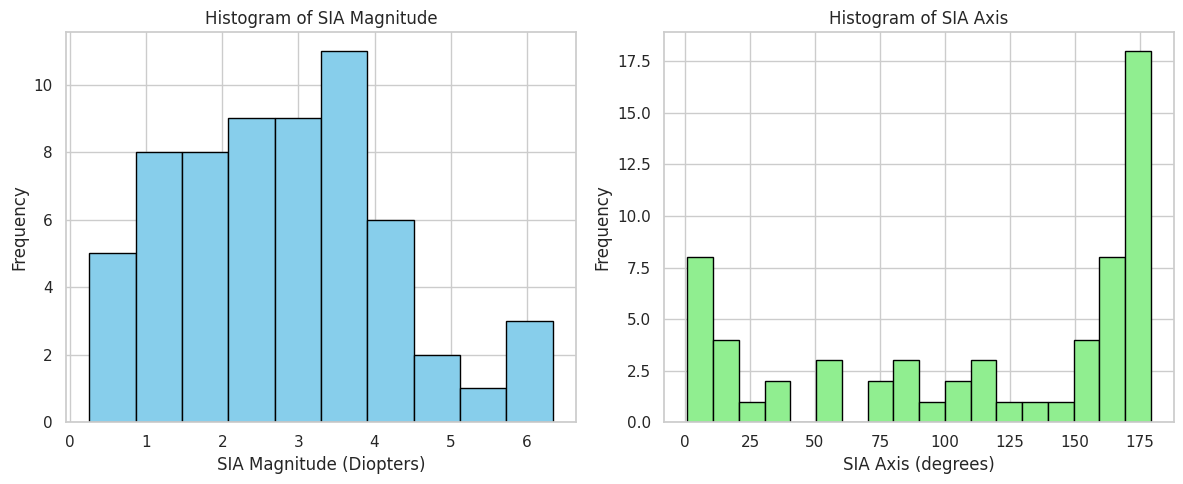

In [175]:
import matplotlib.pyplot as plt

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for SIA Magnitude
axes[0].hist(mixed_df['SIA_magnitude'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of SIA Magnitude')
axes[0].set_xlabel('SIA Magnitude (Diopters)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

# Histogram for SIA Axis
axes[1].hist(mixed_df['SIA_axis'], bins=18, color='lightgreen', edgecolor='black')
axes[1].set_title('Histogram of SIA Axis')
axes[1].set_xlabel('SIA Axis (degrees)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True)

plt.tight_layout()
plt.show()


/tmp/ipython-input-3450680260.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, patch_artist=True,


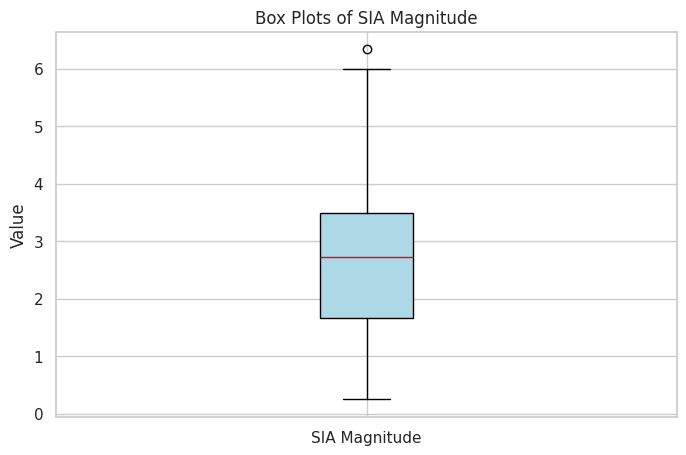

In [176]:
import matplotlib.pyplot as plt

# Extract the two columns
data = [mixed_df['SIA_magnitude'].dropna()]

# Create the box plots side by side
plt.figure(figsize=(8, 5))
plt.boxplot(data, patch_artist=True,
            labels=['SIA Magnitude'],
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red'))

plt.title('Box Plots of SIA Magnitude')
plt.ylabel('Value')
plt.grid(True)
plt.show()


/tmp/ipython-input-1741749712.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, patch_artist=True,


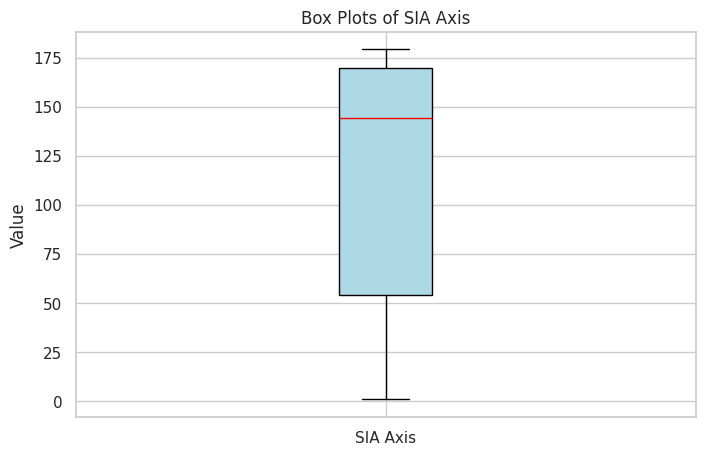

In [178]:
import matplotlib.pyplot as plt

# Extract the two columns
data = [mixed_df['SIA_axis'].dropna()]

# Create the box plots side by side
plt.figure(figsize=(8, 5))
plt.boxplot(data, patch_artist=True,
            labels=['SIA Axis'],
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red'))

plt.title('Box Plots of SIA Axis')
plt.ylabel('Value')
plt.grid(True)
plt.show()


## Compound myopic astigmatism SiA vector analysis